## References
- https://www.kaggle.com/c/ventilator-pressure-prediction/discussion/273974
- https://www.kaggle.com/susnato/lgbm-starter
- https://www.kaggle.com/ryanbarretto/tensorflow-lstm-baseline
- https://www.kaggle.com/akihironomura/tps-lightgbm-optuna-kfold

## Import Modules

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
# from lightgbm import LGBMRegressor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error
import optuna

from warnings import filterwarnings
filterwarnings('ignore')

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/ventilator-pressure-prediction/sample_submission.csv
/kaggle/input/ventilator-pressure-prediction/train.csv
/kaggle/input/ventilator-pressure-prediction/test.csv


In [2]:
train = pd.read_csv('../input/ventilator-pressure-prediction/train.csv')
test = pd.read_csv('../input/ventilator-pressure-prediction/test.csv')
submission = pd.read_csv('../input/ventilator-pressure-prediction/sample_submission.csv')

## EDA

In [3]:
train.head()

,id,breath_id,R,C,time_step,u_in,u_out,pressure
0,1,1,20,50,0.000000,0.083334,0,5.837492
1,2,1,20,50,0.033652,18.383041,0,5.907794
2,3,1,20,50,0.067514,22.509278,0,7.876254
3,4,1,20,50,0.101542,22.808822,0,11.742872
4,5,1,20,50,0.135756,25.355850,0,12.234987


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6036000 entries, 0 to 6035999
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   id         int64  
 1   breath_id  int64  
 2   R          int64  
 3   C          int64  
 4   time_step  float64
 5   u_in       float64
 6   u_out      int64  
 7   pressure   float64
dtypes: float64(3), int64(5)
memory usage: 368.4 MB


In [5]:
train.describe()

,id,breath_id,R,C,time_step,u_in,u_out,pressure
count,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06,6.036000e+06
mean,3.018000e+06,6.283886e+04,2.703618e+01,2.608072e+01,1.307225e+00,7.321615e+00,6.204493e-01,1.122041e+01
std,1.742443e+06,3.633526e+04,1.959549e+01,1.715231e+01,7.659778e-01,1.343470e+01,4.852752e-01,8.109703e+00
min,1.000000e+00,1.000000e+00,5.000000e+00,1.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,-1.895744e+00
25%,1.509001e+06,3.137700e+04,5.000000e+00,1.000000e+01,6.428995e-01,3.936623e-01,0.000000e+00,6.329607e+00
50%,3.018000e+06,6.276550e+04,2.000000e+01,2.000000e+01,1.308123e+00,4.386146e+00,1.000000e+00,7.032628e+00
75%,4.527000e+06,9.430100e+04,5.000000e+01,5.000000e+01,1.965502e+00,4.983895e+00,1.000000e+00,1.364103e+01
max,6.036000e+06,1.257490e+05,5.000000e+01,5.000000e+01,2.937238e+00,1.000000e+02,1.000000e+00,6.482099e+01


In [6]:
train.isnull().sum()

id           0
breath_id    0
R            0
C            0
time_step    0
u_in         0
u_out        0
pressure     0
dtype: int64

In [7]:
train['breath_id'].value_counts()

1         80
83891     80
83924     80
83923     80
83922     80
          ..
41745     80
41743     80
41742     80
41741     80
125749    80
Name: breath_id, Length: 75450, dtype: int64

In [8]:
train['breath_id'].nunique()

75450

<AxesSubplot:xlabel='R', ylabel='count'>

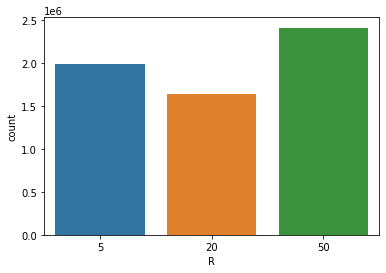

In [9]:
sns.countplot(x=train['R'])

<AxesSubplot:xlabel='C', ylabel='count'>

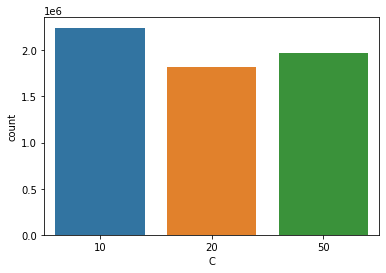

In [10]:
sns.countplot(x=train['C'])

<AxesSubplot:xlabel='u_in'>

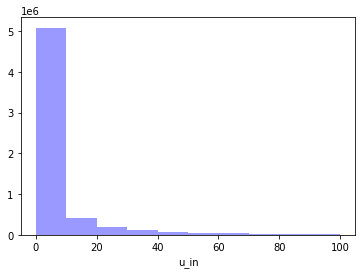

In [11]:
sns.distplot(train['u_in'], kde=False, bins=10, color='blue')

<AxesSubplot:xlabel='u_out'>

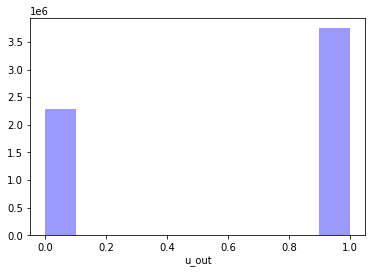

In [12]:
sns.distplot(train['u_out'], kde=False, bins=10, color='blue')

<AxesSubplot:xlabel='pressure'>

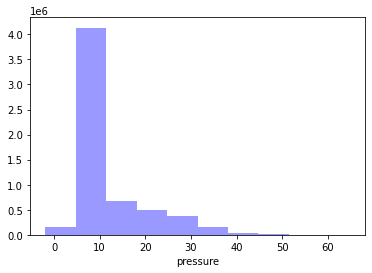

In [13]:
sns.distplot(train['pressure'], kde=False, bins=10, color='blue')

In [14]:
test.head()

,id,breath_id,R,C,time_step,u_in,u_out
0,1,0,5,20,0.000000,0.000000,0
1,2,0,5,20,0.031904,7.515046,0
2,3,0,5,20,0.063827,14.651675,0
3,4,0,5,20,0.095751,21.230610,0
4,5,0,5,20,0.127644,26.320956,0


## Feature Engineering

In [15]:
train['u_in_cumsum'] = train['u_in'].groupby(train['breath_id']).cumsum()
test['u_in_cumsum'] = test['u_in'].groupby(test['breath_id']).cumsum()

In [16]:
train['u_in_lag'] = train['u_in'].shift(2)
train = train.fillna(0)

test['u_in_lag'] = test['u_in'].shift(2)
test = test.fillna(0)

In [17]:
X = train.drop(['id', 'breath_id', 'u_out', 'pressure'], axis = 1)
X_test = test.drop(['id', 'breath_id', 'u_out'], axis = 1)
y = train['pressure']

## Hyperparameter Tuning using Optuna

In [18]:
def objective(trial,data=X,target=y):
    
    X_train, X_valid, y_train, y_valid = train_test_split(data, target, train_size=0.8, test_size=0.2,random_state=0)
        
    params = {
        'objective': 'regression',
        'metric': 'mae', 
        'boosting_type': 'gbdt',
        'n_estimators': 1000,
        'random_state': 42,
        'learning_rate': trial.suggest_categorical('learning_rate', [0.006,0.008,0.01,0.014,0.017,0.02]),
        'subsample': trial.suggest_loguniform('subsample', 0.4, 1.0),
        'subsample_freq': trial.suggest_loguniform('subsample_freq', 0.4, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.4, 1.0),
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 256),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
    }
    model = lgb.LGBMRegressor(**params) 
    model.fit(X_train, y_train)
    
    preds = model.predict(X_valid)
    mae = mean_absolute_error(y_valid, preds)
    
    return mae

In [19]:
# study = optuna.create_study(direction='minimize')
# study.optimize(objective, n_trials=10)
# print('Number of finished trials:', len(study.trials))
# print('Best trial:', study.best_trial.params)

## Model Training

In [20]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, train_size=0.8, test_size=0.2,random_state=0)

In [21]:
lgb_params = {
    'objective': 'regression',
    'metric': 'mae', 
    'boosting_type': 'gbdt',
    'n_estimators': 1000,
    'random_state': 42,
    'learning_rate': 0.017,
    'subsample': 0.6706735076307812,
    'subsample_freq': 0.9731836936473381,
    'colsample_bytree': 0.7981147731267384,
    'reg_alpha': 0.29250836566881794,
    'reg_lambda': 0.0032438602599939702,
    'min_child_weight': 134,
    'min_child_samples': 26,
    'bagging_fraction': 0.6263245217964235,
    'bagging_freq': 1,
}

In [22]:
model = lgb.LGBMRegressor(**lgb_params)
model

LGBMRegressor(bagging_fraction=0.6263245217964235, bagging_freq=1,
              colsample_bytree=0.7981147731267384, learning_rate=0.017,
              metric='mae', min_child_samples=26, min_child_weight=134,
              n_estimators=1000, objective='regression', random_state=42,
              reg_alpha=0.29250836566881794, reg_lambda=0.0032438602599939702,
              subsample=0.6706735076307812, subsample_freq=0.9731836936473381)

In [23]:
model.fit(X_train, y_train)

[LightGBM] [Warning] bagging_fraction is set=0.6263245217964235, subsample=0.6706735076307812 will be ignored. Current value: bagging_fraction=0.6263245217964235
[LightGBM] [Warning] bagging_freq is set=1, subsample_freq=0.9731836936473381 will be ignored. Current value: bagging_freq=1


LGBMRegressor(bagging_fraction=0.6263245217964235, bagging_freq=1,
              colsample_bytree=0.7981147731267384, learning_rate=0.017,
              metric='mae', min_child_samples=26, min_child_weight=134,
              n_estimators=1000, objective='regression', random_state=42,
              reg_alpha=0.29250836566881794, reg_lambda=0.0032438602599939702,
              subsample=0.6706735076307812, subsample_freq=0.9731836936473381)

## Evaluation

In [24]:
pred_valid = model.predict(X_valid)
print('Mean Absolute Error: ', mean_absolute_error(y_valid, pred_valid))

Mean Absolute Error:  0.8785680728141085


## Make Submission

In [25]:
preds = model.predict(X_test)

In [26]:
submission.pressure = preds
submission.head()

,id,pressure
0,1,6.043037
1,2,5.965269
2,3,6.943426
3,4,7.669474
4,5,8.796231


In [27]:
submission.to_csv('submission.csv', index=False)

## If you like this kernel, please upvote:)